# Modelagem, calibração e avaliação temporal

Este notebook compara modelos de regressão para estimar o preço de imóveis. A análise usa separação temporal, validação com janelas expansivas e uma fase específica de calibração para reduzir o viés nos imóveis de maior valor. Todos os resultados são medidos na escala original de dólares.

## 1. Preparação dos dados

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data/raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from property_value_insights.data_contract import load_raw_data  # noqa: E402
from property_value_insights.eda import merge_historical_with_demographics  # noqa: E402
from property_value_insights.modeling import (  # noqa: E402
    build_estimator,
    cross_validate_median_baseline,
    cross_validate_temporal,
    feature_columns,
    fit_and_evaluate,
    median_baseline_prediction,
    regression_metrics,
    segment_metrics,
    select_calibrated_candidate,
    summarize_temporal_validation,
    temporal_train_test_split,
    vertical_equity_metrics,
)

FIGURE_DIR = PROJECT_ROOT / "reports/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
N_SPLITS = 5
SELECTION_TOLERANCE = 0.005
MINIMUM_IMPROVED_FOLDS = 4
REFERENCE_CANDIDATE = "hist_demographics_log_default"
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [2]:
historical, demographics, future = load_raw_data(PROJECT_ROOT / "data/raw")
merged, merge_audit = merge_historical_with_demographics(historical, demographics)

dataset_summary = pd.DataFrame(
    [
        {"dataset": "historical", "rows": len(historical), "columns": len(historical.columns)},
        {
            "dataset": "demographics",
            "rows": len(demographics),
            "columns": len(demographics.columns),
        },
        {"dataset": "future", "rows": len(future), "columns": len(future.columns)},
        {"dataset": "merged_historical", "rows": len(merged), "columns": len(merged.columns)},
    ]
)
display(dataset_summary)
display(
    pd.DataFrame(
        [{
            "historical_rows": merge_audit.historical_rows,
            "merged_rows": merge_audit.merged_rows,
            "zipcode_coverage_pct": merge_audit.zipcode_coverage_pct,
            "unmatched_rows": merge_audit.unmatched_rows,
        }]
    )
)


,dataset,rows,columns
0,historical,21613,21
1,demographics,70,27
2,future,100,18
3,merged_historical,21613,47


,historical_rows,merged_rows,zipcode_coverage_pct,unmatched_rows
0,21613,21613,100.0000,0


## 2. Protocolo de avaliação

- As datas são ordenadas antes da divisão.
- As datas mais recentes formam o teste temporal e não participam da busca.
- A validação usa cinco janelas temporais expansivas no conjunto de desenvolvimento.
- O `id` é excluído das variáveis e o `zipcode` é tratado como categoria.
- Os dados demográficos são comparados por ablação.
- A busca é limitada, determinística e usa os mesmos folds para todos os candidatos.
- MAE e RMSE em dólares são as métricas gerais; MAPE, erro médio, taxa de subestimação, razão mediana e PRD complementam a análise vertical.
- A faixa superior é definida pelo terceiro quartil do respectivo conjunto de treino.

Uma calibração somente é promovida quando permanece dentro de 0,5% da melhor MAE geral, melhora o MAE e o viés absoluto da faixa superior e supera a referência em pelo menos quatro dos cinco folds. O teste temporal é apresentado como diagnóstico, pois seus resíduos motivaram esta revisão e ele não deve ser tratado novamente como um conjunto completamente intocado.

In [3]:
split = temporal_train_test_split(merged, test_size=0.2)
split_summary = pd.DataFrame(
    [{
        "development_rows": len(split.train),
        "test_rows": len(split.test),
        "development_end": split.train_end.date(),
        "test_start": split.test_start.date(),
        "test_share": len(split.test) / len(merged),
    }]
)
display(split_summary)


,development_rows,test_rows,development_end,test_start,test_share
0,16973,4640,2015-03-03,2015-03-04,0.2147


## 3. Candidatos e configurações

In [4]:
candidates = [
    {
        "candidate": "baseline_median",
        "model_name": None,
        "feature_set": "physical",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "ridge_physical_raw",
        "model_name": "ridge",
        "feature_set": "physical",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "ridge_physical_log",
        "model_name": "ridge",
        "feature_set": "physical",
        "target_transform": "log",
        "model_params": {},
    },
    {
        "candidate": "ridge_demographics_raw",
        "model_name": "ridge",
        "feature_set": "with_demographics",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "ridge_demographics_log",
        "model_name": "ridge",
        "feature_set": "with_demographics",
        "target_transform": "log",
        "model_params": {},
    },
    {
        "candidate": "hist_physical_raw",
        "model_name": "hist_gradient_boosting",
        "feature_set": "physical",
        "target_transform": "raw",
        "model_params": {},
    },
    {
        "candidate": "hist_physical_log",
        "model_name": "hist_gradient_boosting",
        "feature_set": "physical",
        "target_transform": "log",
        "model_params": {},
    },
]

search_params = {
    "default": {},
    "regularized": {
        "learning_rate": 0.04,
        "max_iter": 500,
        "max_leaf_nodes": 31,
        "l2_regularization": 1.0,
    },
    "compact": {
        "learning_rate": 0.05,
        "max_iter": 400,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.5,
    },
    "wide": {
        "learning_rate": 0.04,
        "max_iter": 400,
        "max_leaf_nodes": 63,
        "l2_regularization": 1.0,
    },
}

for target_transform in ["raw", "log"]:
    for label, model_params in search_params.items():
        candidates.append(
            {
                "candidate": f"hist_demographics_{target_transform}_{label}",
                "model_name": "hist_gradient_boosting",
                "feature_set": "with_demographics",
                "target_transform": target_transform,
                "model_params": model_params,
            }
        )

calibration_candidates = [
    {
        "candidate": "hist_demographics_log_smearing",
        "model_name": "hist_gradient_boosting",
        "feature_set": "with_demographics",
        "target_transform": "log_smearing",
        "model_params": {},
    },
    {
        "candidate": "hist_demographics_log_temporal_smearing_10",
        "model_name": "hist_gradient_boosting",
        "feature_set": "with_demographics",
        "target_transform": "log_temporal_smearing",
        "model_params": {"calibration_fraction": 0.1},
    },
    {
        "candidate": "hist_demographics_log_temporal_smearing_20",
        "model_name": "hist_gradient_boosting",
        "feature_set": "with_demographics",
        "target_transform": "log_temporal_smearing",
        "model_params": {"calibration_fraction": 0.2},
    },
    {
        "candidate": "hist_demographics_gamma_default",
        "model_name": "hist_gradient_boosting",
        "feature_set": "with_demographics",
        "target_transform": "raw",
        "model_params": {"loss": "gamma"},
    },
    {
        "candidate": "hist_demographics_poisson_default",
        "model_name": "hist_gradient_boosting",
        "feature_set": "with_demographics",
        "target_transform": "raw",
        "model_params": {"loss": "poisson"},
    },
    {
        "candidate": "hist_demographics_absolute_default",
        "model_name": "hist_gradient_boosting",
        "feature_set": "with_demographics",
        "target_transform": "raw",
        "model_params": {"loss": "absolute_error"},
    },
    {
        "candidate": "hist_physical_log_temporal_smearing_10",
        "model_name": "hist_gradient_boosting",
        "feature_set": "physical",
        "target_transform": "log_temporal_smearing",
        "model_params": {"calibration_fraction": 0.1},
    },
]

candidates.extend(calibration_candidates)
calibration_candidate_names = {
    REFERENCE_CANDIDATE,
    *(item["candidate"] for item in calibration_candidates),
}
candidate_specs = {item["candidate"]: item for item in candidates}

display(
    pd.DataFrame(
        [
            {
                "candidate": item["candidate"],
                "model": item["model_name"] or "median",
                "features": item["feature_set"],
                "target": item["target_transform"],
                "parameters": item["model_params"],
            }
            for item in candidates
        ]
    )
)

,candidate,model,features,target,parameters
0,baseline_median,median,physical,raw,{}
1,ridge_physical_raw,ridge,physical,raw,{}
2,ridge_physical_log,ridge,physical,log,{}
3,ridge_demographics_raw,ridge,with_demographics,raw,{}
4,ridge_demographics_log,ridge,with_demographics,log,{}
5,hist_physical_raw,hist_gradient_boosting,physical,raw,{}
6,hist_physical_log,hist_gradient_boosting,physical,log,{}
7,hist_demographics_raw_default,hist_gradient_boosting,with_demographics,raw,{}
8,hist_demographics_raw_regularized,hist_gradient_boosting,with_demographics,raw,"{'learning_rate': 0.04, 'max_iter': 500, 'max_..."
9,hist_demographics_raw_compact,hist_gradient_boosting,with_demographics,raw,"{'learning_rate': 0.05, 'max_iter': 400, 'max_..."


## 4. Validação temporal e promoção da calibração

In [5]:
cv_results = {}

for item in candidates:
    name = item["candidate"]
    if item["model_name"] is None:
        cv = cross_validate_median_baseline(split.train, n_splits=N_SPLITS)
    else:
        estimator = build_estimator(
            item["model_name"],
            item["feature_set"],
            target_transform=item["target_transform"],
            model_params=item["model_params"],
        )
        cv = cross_validate_temporal(
            estimator,
            split.train,
            feature_set=item["feature_set"],
            n_splits=N_SPLITS,
        )
    cv_results[name] = cv

validation_results = summarize_temporal_validation(
    cv_results,
    reference_candidate=REFERENCE_CANDIDATE,
)
calibration_results = validation_results.loc[
    validation_results["candidate"].isin(calibration_candidate_names)
].reset_index(drop=True)
selection = select_calibrated_candidate(
    calibration_results,
    reference_candidate=REFERENCE_CANDIDATE,
    relative_tolerance=SELECTION_TOLERANCE,
    minimum_improved_folds=MINIMUM_IMPROVED_FOLDS,
)
champion_name = selection.champion

roles = {REFERENCE_CANDIDATE: "referência", champion_name: "modelo promovido"}
decision_summary = calibration_results.loc[
    calibration_results["candidate"].isin(roles)
].copy()
decision_summary["role"] = decision_summary["candidate"].map(roles)
decision_summary["role_order"] = decision_summary["role"].map(
    {"modelo promovido": 0, "referência": 1}
)
decision_summary = (
    decision_summary.sort_values("role_order")
    .drop(columns="role_order")
    .reset_index(drop=True)
)
validation_schedule = cv_results[champion_name][
    [
        "fold",
        "train_end",
        "validation_start",
        "validation_end",
        "train_rows",
        "validation_rows",
        "high_price_threshold",
        "high_price_rows",
    ]
]

validation_display_columns = [
    "candidate",
    "cv_mae_mean",
    "cv_mae_std",
    "cv_mae_worst",
    "cv_rmse_mean",
    "cv_rmsle_mean",
]
calibration_display_columns = [
    "candidate",
    "cv_mae_mean",
    "cv_mape_mean",
    "cv_mean_error_mean",
    "cv_underprediction_rate_mean",
    "cv_prd_mean",
    "cv_high_price_mae_mean",
    "cv_high_price_mean_error_mean",
    "cv_high_price_underprediction_rate_mean",
    "high_price_mae_improved_folds",
]

display(validation_results[validation_display_columns])
display(calibration_results[calibration_display_columns])
display(decision_summary[calibration_display_columns + ["role"]])
display(validation_schedule)

reference_spec = candidate_specs[REFERENCE_CANDIDATE]
champion_spec = candidate_specs[champion_name]
reference_estimator = build_estimator(
    reference_spec["model_name"],
    reference_spec["feature_set"],
    target_transform=reference_spec["target_transform"],
    model_params=reference_spec["model_params"],
)
champion_estimator = build_estimator(
    champion_spec["model_name"],
    champion_spec["feature_set"],
    target_transform=champion_spec["target_transform"],
    model_params=champion_spec["model_params"],
)
reference_evaluation = fit_and_evaluate(
    reference_estimator,
    split.train,
    split.test,
    feature_set=reference_spec["feature_set"],
)
champion_evaluation = fit_and_evaluate(
    champion_estimator,
    split.train,
    split.test,
    feature_set=champion_spec["feature_set"],
)
baseline_predictions = median_baseline_prediction(split.train, split.test)

holdout_predictions = {
    "baseline_median": baseline_predictions,
    REFERENCE_CANDIDATE: reference_evaluation.predictions,
    champion_name: champion_evaluation.predictions,
}
holdout_results = pd.DataFrame(
    [
        {
            "candidate": name,
            **regression_metrics(split.test["price"], predictions),
            **vertical_equity_metrics(split.test["price"], predictions),
        }
        for name, predictions in holdout_predictions.items()
    ]
)
display(holdout_results)

baseline_row = holdout_results.loc[
    holdout_results["candidate"] == "baseline_median"
].iloc[0]
champion_row = holdout_results.loc[
    holdout_results["candidate"] == champion_name
].iloc[0]
reference_row = holdout_results.loc[
    holdout_results["candidate"] == REFERENCE_CANDIDATE
].iloc[0]
comparison_rows = []
for metric in ["mae", "rmse", "rmsle"]:
    baseline_value = float(baseline_row[metric])
    champion_value = float(champion_row[metric])
    comparison_rows.append(
        {
            "metric": metric.upper(),
            "median_baseline": baseline_value,
            "champion": champion_value,
            "relative_reduction_pct": (
                (baseline_value - champion_value) / baseline_value * 100
            ),
            "absolute_change": champion_value - baseline_value,
        }
    )
comparison_rows.append(
    {
        "metric": "R2",
        "median_baseline": float(baseline_row["r2"]),
        "champion": float(champion_row["r2"]),
        "relative_reduction_pct": None,
        "absolute_change": float(champion_row["r2"] - baseline_row["r2"]),
    }
)
comparison = pd.DataFrame(comparison_rows)
comparison_display = comparison.copy()
for column in ["median_baseline", "champion", "absolute_change"]:
    comparison_display[column] = comparison_display[column].map(lambda value: f"{value:,.3f}")
comparison_display["relative_reduction_pct"] = comparison[
    "relative_reduction_pct"
].map(lambda value: "-" if pd.isna(value) else f"{value:.1f}%")
mae_reduction_pct = comparison.loc[
    comparison["metric"] == "MAE", "relative_reduction_pct"
].iloc[0]
display(comparison_display)

,candidate,cv_mae_mean,cv_mae_std,cv_mae_worst,cv_rmse_mean,cv_rmsle_mean
0,hist_demographics_log_smearing,"62,962.5713","1,355.3636","64,918.2253","117,011.3080",0.1644
1,hist_demographics_log_default,"63,128.3704","1,547.4509","65,603.1557","117,518.9681",0.1646
2,hist_demographics_log_temporal_smearing_10,"63,154.7804","1,567.7497","65,740.7900","116,561.3111",0.1650
3,hist_demographics_log_regularized,"63,174.2804","1,498.9705","65,856.5398","118,599.3528",0.1645
4,hist_demographics_log_temporal_smearing_20,"63,181.6488","1,576.6814","65,694.6861","116,578.1756",0.1650
5,hist_demographics_gamma_default,"63,256.8443","1,108.7716","65,147.8879","119,645.0684",0.1642
6,hist_physical_log_temporal_smearing_10,"63,431.8707","2,025.9325","66,875.8906","118,528.0782",0.1660
7,hist_physical_log,"63,446.1268","1,987.5924","65,887.7911","119,528.9516",0.1657
8,hist_demographics_log_compact,"63,448.3591","1,591.9895","66,517.9838","118,678.3960",0.1639
9,hist_demographics_poisson_default,"63,476.4749",588.8809,"64,497.7738","118,304.1624",0.1651


,candidate,cv_mae_mean,cv_mape_mean,cv_mean_error_mean,cv_underprediction_rate_mean,cv_prd_mean,cv_high_price_mae_mean,cv_high_price_mean_error_mean,cv_high_price_underprediction_rate_mean,high_price_mae_improved_folds
0,hist_demographics_log_smearing,"62,962.5713",0.1193,"-8,775.6547",0.5194,1.0290,"128,907.1255","-54,671.0024",0.6266,5
1,hist_demographics_log_default,"63,128.3704",0.1190,"-11,579.3703",0.5373,1.0290,"130,027.9650","-59,767.7314",0.6452,0
2,hist_demographics_log_temporal_smearing_10,"63,154.7804",0.1210,"-2,194.7020",0.4788,1.0290,"127,277.6685","-42,838.9080",0.5861,4
3,hist_demographics_log_temporal_smearing_20,"63,181.6488",0.1210,"-2,554.2536",0.4809,1.0290,"127,428.9544","-43,533.8095",0.5863,5
4,hist_demographics_gamma_default,"63,256.8443",0.1195,"-8,402.9421",0.5196,1.0289,"130,320.3761","-52,948.7174",0.6236,2
5,hist_physical_log_temporal_smearing_10,"63,431.8707",0.1213,"-2,016.6437",0.4779,1.0288,"127,964.3447","-42,684.0028",0.5972,3
6,hist_demographics_poisson_default,"63,476.4749",0.1206,"-6,985.1151",0.5132,1.0302,"130,158.1661","-51,304.8940",0.6205,2
7,hist_demographics_absolute_default,"64,731.1018",0.1210,"-10,173.9347",0.5157,1.0370,"137,560.2453","-66,119.9677",0.6480,0


,candidate,cv_mae_mean,cv_mape_mean,cv_mean_error_mean,cv_underprediction_rate_mean,cv_prd_mean,cv_high_price_mae_mean,cv_high_price_mean_error_mean,cv_high_price_underprediction_rate_mean,high_price_mae_improved_folds,role
0,hist_demographics_log_temporal_smearing_10,"63,154.7804",0.1210,"-2,194.7020",0.4788,1.0290,"127,277.6685","-42,838.9080",0.5861,4,modelo promovido
1,hist_demographics_log_default,"63,128.3704",0.1190,"-11,579.3703",0.5373,1.0290,"130,027.9650","-59,767.7314",0.6452,0,referência


,fold,train_end,validation_start,validation_end,train_rows,validation_rows,high_price_threshold,high_price_rows
0,1,2014-06-22,2014-06-23,2014-08-10,3235,3442,"660,000.0000",840
1,2,2014-08-10,2014-08-11,2014-09-28,6677,3058,"657,000.0000",698
2,3,2014-09-28,2014-09-29,2014-11-16,9735,2792,"650,000.0000",664
3,4,2014-11-16,2014-11-17,2015-01-10,12527,2392,"649,000.0000",563
4,5,2015-01-10,2015-01-12,2015-03-03,14919,2054,"645,000.0000",440


,candidate,mae,rmse,rmsle,r2,median_absolute_error,mape,mean_error,mean_percentage_error,underprediction_rate,median_prediction_ratio,coefficient_of_dispersion,price_related_differential
0,baseline_median,"225,353.8853","382,414.5500",0.5250,-0.0790,"149,600.0000",0.4097,"-103,465.4466",0.0717,0.5304,0.9678,42.2629,1.3184
1,hist_demographics_log_default,"73,912.4389","129,023.8004",0.1818,0.8772,"44,598.5181",0.1289,"-43,927.8127",-0.0531,0.7147,0.9319,12.1739,1.0286
2,hist_demographics_log_temporal_smearing_10,"67,455.9069","120,406.8921",0.1700,0.8930,"39,888.9647",0.1209,"-20,891.8611",-0.0102,0.5890,0.9740,12.1739,1.0286


,metric,median_baseline,champion,relative_reduction_pct,absolute_change
0,MAE,"225,353.885","67,455.907",70.1%,"-157,897.978"
1,RMSE,"382,414.550","120,406.892",68.5%,"-262,007.658"
2,RMSLE,0.525,0.170,67.6%,-0.355
3,R2,-0.079,0.893,-,0.972


## 5. Diagnóstico vertical e análise por segmentos

In [6]:
selection_summary = pd.DataFrame(
    [
        {
            "reference": selection.reference,
            "champion": champion_name,
            "promoted": selection.promoted,
            "relative_tolerance_pct": selection.relative_tolerance * 100,
            "minimum_improved_folds": selection.minimum_improved_folds,
            "holdout_status": "diagnóstico após seleção temporal",
        }
    ]
)
display(selection_summary)

holdout = split.test.copy()
holdout["prediction"] = champion_evaluation.predictions.to_numpy()
holdout["price_band"] = pd.qcut(holdout["price"], q=4, duplicates="drop")
holdout["month"] = pd.to_datetime(holdout["date"]).dt.to_period("M").astype(str)

price_band_errors = segment_metrics(
    holdout["price"],
    holdout["prediction"],
    holdout["price_band"],
    segment_name="price_band",
)
monthly_errors = segment_metrics(
    holdout["price"],
    holdout["prediction"],
    holdout["month"],
    segment_name="month",
)
zipcode_errors = segment_metrics(
    holdout["price"],
    holdout["prediction"],
    holdout["zipcode"],
    segment_name="zipcode",
).query("rows >= 20").sort_values("mae", ascending=False)

high_price_threshold = float(split.train["price"].quantile(0.75))
high_mask = split.test["price"] >= high_price_threshold
tail_holdout_results = pd.DataFrame(
    [
        {
            "candidate": name,
            "threshold": high_price_threshold,
            "rows": int(high_mask.sum()),
            **regression_metrics(
                split.test.loc[high_mask, "price"],
                predictions.loc[high_mask],
            ),
            **vertical_equity_metrics(
                split.test.loc[high_mask, "price"],
                predictions.loc[high_mask],
            ),
        }
        for name, predictions in holdout_predictions.items()
        if name != "baseline_median"
    ]
)

segment_display_columns = [
    "price_band",
    "rows",
    "mae",
    "mape",
    "mean_error",
    "underprediction_rate",
    "median_prediction_ratio",
    "price_related_differential",
]
monthly_display_columns = [
    "month",
    "rows",
    "mae",
    "mape",
    "mean_error",
    "underprediction_rate",
    "median_prediction_ratio",
]
tail_display_columns = [
    "candidate",
    "threshold",
    "rows",
    "mae",
    "mape",
    "mean_error",
    "underprediction_rate",
    "median_prediction_ratio",
    "price_related_differential",
]

display(tail_holdout_results[tail_display_columns])
display(price_band_errors[segment_display_columns])
display(monthly_errors[monthly_display_columns])
display(zipcode_errors.head(10))

,reference,champion,promoted,relative_tolerance_pct,minimum_improved_folds,holdout_status
0,hist_demographics_log_default,hist_demographics_log_temporal_smearing_10,True,0.5000,4,diagnóstico após seleção temporal


,candidate,threshold,rows,mae,mape,mean_error,underprediction_rate,median_prediction_ratio,price_related_differential
0,hist_demographics_log_default,"640,000.0000",1246,"146,699.1973",0.1388,"-109,978.1061",0.7953,0.8999,1.0102
1,hist_demographics_log_temporal_smearing_10,"640,000.0000",1246,"131,242.9584",0.1231,"-70,639.7192",0.6894,0.9407,1.0102


,price_band,rows,mae,mape,mean_error,underprediction_rate,median_prediction_ratio,price_related_differential
0,"(80999.999, 330000.0]",1169,"35,332.4969",0.1491,"12,512.6199",0.4508,1.0175,1.0173
1,"(330000.0, 464475.0]",1151,"44,420.4877",0.1114,"-5,800.1956",0.5995,0.9741,1.0007
2,"(464475.0, 655000.0]",1162,"53,988.0277",0.0979,"-16,811.8892",0.6119,0.9692,1.0004
3,"(655000.0, 5350000.0]",1158,"136,295.0345",0.1249,"-73,708.1587",0.6952,0.9390,1.0103


,month,rows,mae,mape,mean_error,underprediction_rate,median_prediction_ratio
0,2015-03,1763,"62,837.9253",0.1189,"-12,269.8155",0.5440,0.9871
1,2015-04,2231,"68,724.9574",0.1203,"-22,939.0093",0.6087,0.9682
2,2015-05,646,"75,676.1084",0.1282,"-37,352.3544",0.6440,0.9568


,zipcode,rows,mae,rmse,rmsle,r2,median_absolute_error,mape,mean_error,mean_percentage_error,underprediction_rate,median_prediction_ratio,coefficient_of_dispersion,price_related_differential
48,98112,47,"200,706.9116","299,200.5139",0.1850,0.7866,"122,605.1421",0.1431,"-78,203.1228",-0.0366,0.6809,0.9439,13.9491,1.0254
3,98004,63,"197,075.9603","281,041.3303",0.1547,0.8917,"150,238.8811",0.1258,"-46,220.6673",-0.0124,0.5714,0.9726,12.7972,1.0191
25,98040,67,"156,490.6304","255,617.6059",0.1582,0.8354,"79,792.7374",0.1161,"-53,093.4475",-0.0223,0.6269,0.9668,11.4900,1.0219
5,98006,98,"143,278.6368","289,298.9339",0.1912,0.7638,"66,762.9800",0.1324,"-69,412.9561",-0.0089,0.6327,0.9764,13.2002,1.0697
43,98105,49,"137,621.4492","191,536.1938",0.1642,0.9130,"107,004.9633",0.1342,"-49,545.4484",-0.0152,0.5306,0.9864,13.5466,1.0377
69,98199,68,"117,046.8257","200,214.5768",0.1717,0.7935,"71,138.6626",0.1289,"-23,445.2925",0.0087,0.4412,1.0177,12.4788,1.0375
4,98005,33,"102,960.6210","136,604.0719",0.1619,0.8343,"69,757.7676",0.1224,"-51,232.3287",-0.0434,0.7273,0.9369,11.1260,1.0175
49,98115,135,"94,317.1184","132,737.7238",0.1974,0.6595,"68,985.5468",0.1363,"-48,989.8522",-0.0481,0.6444,0.9302,13.5971,1.0287
21,98033,98,"91,954.8406","145,471.3829",0.1558,0.8407,"60,312.1924",0.1075,"-55,493.6763",-0.0511,0.6633,0.9477,10.5753,1.0220
45,98107,57,"89,363.4707","208,976.9633",0.1793,0.6176,"46,745.9561",0.1084,"-63,778.4984",-0.0586,0.6667,0.9462,10.1756,1.0425


## 6. Importância das variáveis

In [7]:
selected_features = feature_columns(champion_spec["feature_set"])
importance_result = permutation_importance(
    champion_evaluation.estimator,
    split.test[selected_features],
    split.test["price"],
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
feature_importance = (
    pd.DataFrame(
        {
            "feature": selected_features,
            "mae_increase": importance_result.importances_mean,
            "mae_std": importance_result.importances_std,
        }
    )
    .sort_values("mae_increase", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance.head(15))


,feature,mae_increase,mae_std
0,sqft_living,"57,049.7347",501.9104
1,lat,"52,916.9683",704.8514
2,grade,"40,388.4989",634.3694
3,per_bchlr,"14,462.0491",125.9968
4,per_prfsnl,"12,818.9729",187.8906
5,long,"9,971.6562",271.2515
6,sqft_lot,"9,803.9362",126.4826
7,hous_val_amt,"8,210.0990",193.3719
8,yr_built,"6,317.6840",365.1674
9,view,"6,177.8794",211.5035


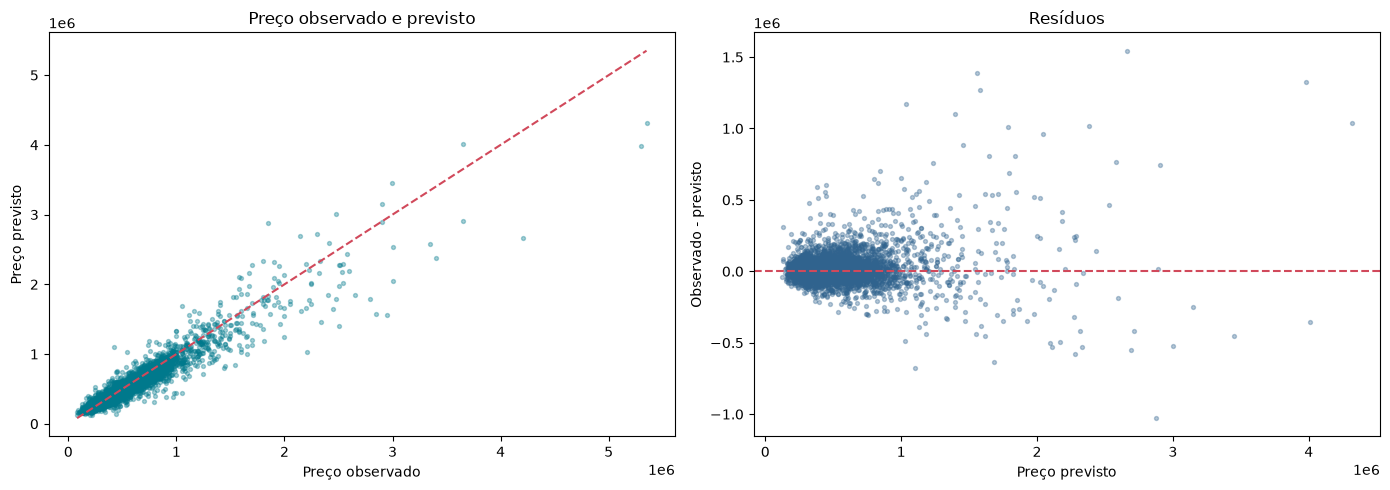

In [8]:
actual = split.test["price"].to_numpy()
predicted = champion_evaluation.predictions.to_numpy()
residuals = actual - predicted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(actual, predicted, s=8, alpha=0.35, color="#00798c")
limits = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
axes[0].plot(limits, limits, linestyle="--", color="#d1495b")
axes[0].set_title("Preço observado e previsto")
axes[0].set_xlabel("Preço observado")
axes[0].set_ylabel("Preço previsto")

axes[1].scatter(predicted, residuals, s=8, alpha=0.35, color="#30638e")
axes[1].axhline(0, linestyle="--", color="#d1495b")
axes[1].set_title("Resíduos")
axes[1].set_xlabel("Preço previsto")
axes[1].set_ylabel("Observado - previsto")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Registro dos resultados

In [9]:
report_path = PROJECT_ROOT / "reports/model_comparison.md"
report_lines = [
    "# Relatório de modelagem, calibração e avaliação",
    "",
    (
        "> **Contexto do experimento:** este relatório registra a promoção estatística "
        "dos candidatos calibrados. A avaliação de governança posterior selecionou o "
        "modelo somente físico como artefato final. Portanto, as seções \"modelo "
        "promovido\" e \"importância das variáveis\" abaixo descrevem o experimento "
        "demográfico e não o modelo servido pela API. Os resultados vigentes estão em "
        "[`training_summary.md`](training_summary.md), "
        "[`MODEL_CARD.md`](../docs/MODEL_CARD.md) e "
        "[`stakeholder_summary.md`](stakeholder_summary.md)."
    ),
    "",
    "## Protocolo",
    "",
    f"- Linhas de desenvolvimento: {len(split.train):,}.",
    f"- Linhas do teste temporal: {len(split.test):,}.",
    f"- Última data do desenvolvimento: {split.train_end.date()}.",
    f"- Primeira data do teste: {split.test_start.date()}.",
    "- Validação: cinco janelas temporais expansivas com datas completas.",
    "- Faixa superior: valores iguais ou superiores ao terceiro quartil do treino de cada fold.",
    "- Margem máxima para a MAE geral: 0,5% em relação ao melhor candidato e à referência.",
    "- Promoção: melhora do MAE e do viés absoluto da faixa superior em pelo menos quatro folds.",
    "- O teste temporal não participa da seleção da calibração.",
    "",
    "## Validação temporal geral",
    "",
    validation_results[validation_display_columns].to_markdown(index=False, floatfmt=".3f"),
    "",
    "## Candidatos calibrados",
    "",
    calibration_results[calibration_display_columns].to_markdown(index=False, floatfmt=".4f"),
    "",
    (
        "As métricas de razão são diagnósticos adaptados para monitoramento "
        "preditivo e não representam uma avaliação formal de conformidade tributária."
    ),
    "",
    "## Decisão de promoção",
    "",
    decision_summary[calibration_display_columns + ["role"]].to_markdown(
        index=False,
        floatfmt=".4f",
    ),
    "",
    (
        f"O modelo `{champion_name}` foi promovido porque permaneceu dentro da margem de "
        f"{selection.relative_tolerance:.1%}, reduziu o MAE e o viés absoluto da faixa "
        f"superior e melhorou pelo menos {selection.minimum_improved_folds} folds."
    ),
    "",
    "## Janelas temporais do modelo promovido",
    "",
    validation_schedule.to_markdown(index=False),
    "",
    "## Avaliação temporal diagnóstica",
    "",
    (
        "Os resíduos deste período motivaram a calibração adicional. Por isso, os resultados "
        "abaixo são diagnósticos posteriores à seleção temporal e não um novo "
        "teste completamente intocado."
    ),
    "",
    holdout_results.to_markdown(index=False, floatfmt=".4f"),
    "",
    "## Comparação com a mediana",
    "",
    comparison_display.to_markdown(index=False),
    "",
    f"A MAE do modelo promovido foi reduzida em {mae_reduction_pct:.1f}% em relação à mediana.",
    (
        f"O R² passou de {baseline_row['r2']:.3f} na mediana para "
        f"{champion_row['r2']:.3f} no modelo promovido."
    ),
    "",
    "## Faixa superior no período diagnóstico",
    "",
    tail_holdout_results[tail_display_columns].to_markdown(index=False, floatfmt=".4f"),
    "",
    "## Erro por faixa de preço",
    "",
    price_band_errors[segment_display_columns].to_markdown(index=False, floatfmt=".4f"),
    "",
    "## Erro mensal",
    "",
    monthly_errors[monthly_display_columns].to_markdown(index=False, floatfmt=".4f"),
    "",
    "## Maiores erros por CEP",
    "",
    zipcode_errors.head(10).to_markdown(index=False, floatfmt=".4f"),
    "",
    "## Variáveis com maior impacto na MAE",
    "",
    feature_importance.head(15).to_markdown(index=False, floatfmt=".4f"),
    "",
    (
        "O desempenho deve ser interpretado junto com a distribuição temporal, "
        "as faixas de preço e a cobertura dos CEPs observados."
    ),
    "",
]
report_path.write_text(chr(10).join(report_lines), encoding="utf-8")
print("Relatório de modelagem atualizado.")

Relatório de modelagem atualizado.


In [10]:
assert len(split.train) + len(split.test) == len(merged)
assert split.train_end < split.test_start
assert len(cv_results) == len(candidates)
assert all(len(scores) == N_SPLITS for scores in cv_results.values())
assert validation_results["cv_mae_mean"].notna().all()
assert selection.promoted
assert champion_name != REFERENCE_CANDIDATE
assert int(
    calibration_results.loc[
        calibration_results["candidate"] == champion_name,
        "high_price_mae_improved_folds",
    ].iloc[0]
) >= MINIMUM_IMPROVED_FOLDS
assert set(holdout_results["candidate"]) == {
    "baseline_median",
    REFERENCE_CANDIDATE,
    champion_name,
}